In [15]:
# I need to  Import Libraries & Load Dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import  GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

FILE_PATH = 'used_cars_price_prediction.csv'   

df_raw = pd.read_csv(FILE_PATH)
print(f'Loaded {len(df_raw):,} rows  {df_raw.shape[1]} columns')
df_raw.head(5)

Loaded 4,009 rows  12 columns


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [17]:
# Data cleaning

df = df_raw.copy()

# Numeric columns stored as strings
df['price']  = df['price'].str.replace(r'[$,]', '', regex=True).astype(float)
df['milage'] = df['milage'].str.replace(r'[^\d]', '', regex=True).astype(float) 

# Extract numeric fields from the engine description string
df['horsepower']    = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
df['engine_size_L'] = df['engine'].str.extract(r'(\d+\.\d+)L').astype(float)
df['cylinders']     = df['engine'].str.extract(r'(\d+) Cylinder').astype(float)

# Remove top-1% price outliers (exotic/collectible cars hurt generalisation)
p99 = df['price'].quantile(0.99)
df  = df[df['price'] <= p99].copy()
print(f'Rows after removing prices above ${p99:,.0f}: {len(df):,}')

# Log-transform target — fixes the heavy right-skew
df['log_price'] = np.log1p(df['price'])

# Fill missing fuel type
df.fillna({'fuel_type': 'Unknown'}, inplace=True)

print('\nMissing values remaining:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Rows after removing prices above $272,713: 3,968

Missing values remaining:
accident         113
clean_title      586
horsepower       779
engine_size_L    393
cylinders        917
dtype: int64


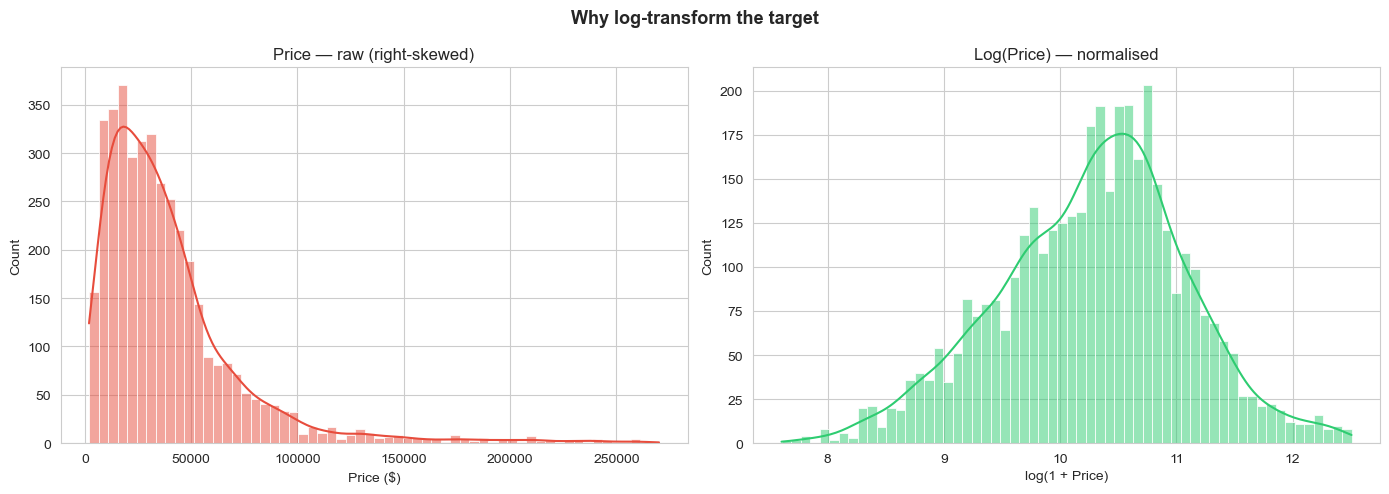

In [18]:
#EDA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], bins=60, kde=True, ax=axes[0], color='#e74c3c')
axes[0].set_title('Price — raw (right-skewed)')
axes[0].set_xlabel('Price ($)')

sns.histplot(df['log_price'], bins=60, kde=True, ax=axes[1], color='#2ecc71')
axes[1].set_title('Log(Price) — normalised')
axes[1].set_xlabel('log(1 + Price)')

plt.suptitle('Why log-transform the target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

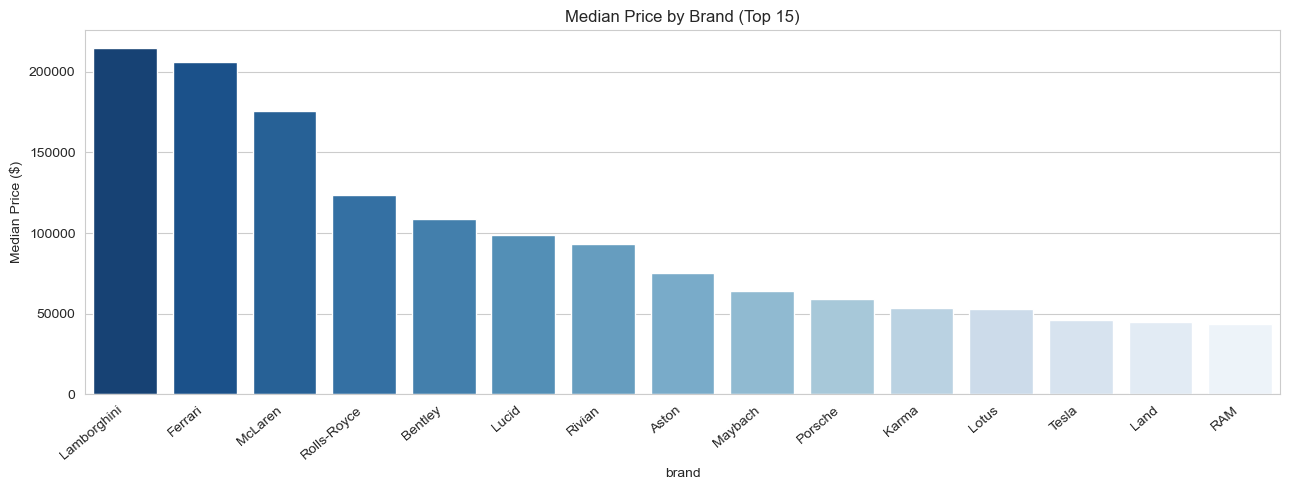

In [19]:
# Average price by brand (top 15)
brand_avg = df.groupby('brand')['price'].median().sort_values(ascending=False).head(15)


plt.figure(figsize=(13, 5))
sns.barplot(x=brand_avg.index, y=brand_avg.values, hue=brand_avg.index, palette='Blues_r', legend=False)
plt.title('Median Price by Brand (Top 15)')
plt.xticks(rotation=40, ha='right')
plt.ylabel('Median Price ($)')
plt.tight_layout()
plt.show()

In [20]:
# Encode categorical variables

label_encoders = {}
categorical_cols = ['brand', 'fuel_type', 'transmission']

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"✓ {col}: {len(le.classes_)} classes encoded")

✓ brand: 56 classes encoded
✓ fuel_type: 8 classes encoded
✓ transmission: 60 classes encoded


In [21]:
 # Creating the missing engineered features first

df['car_age'] = 2025 - df['model_year']  # adjust 2025 to current year if needed

df['milage_per_year'] = df['milage'] / df['car_age'].replace(0, 1)  # avoid division by zero
df['power_per_liter'] = df['horsepower'] / df['engine_size_L']

# Now define features with correct column names

feature_cols = [
    'model_year', 'milage', 'horsepower', 'engine_size_L', 'cylinders',
    'car_age', 'milage_per_year', 'power_per_liter',
    'brand_encoded', 'fuel_type_encoded', 'transmission_encoded'
]

X = df[feature_cols].copy()
y = df['price'].copy()

print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X)}")
print(f"\nFeature columns: {feature_cols}")

Features: 11
Samples: 3968

Feature columns: ['model_year', 'milage', 'horsepower', 'engine_size_L', 'cylinders', 'car_age', 'milage_per_year', 'power_per_liter', 'brand_encoded', 'fuel_type_encoded', 'transmission_encoded']


In [22]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Split ratio: 80-20")

Training set: 3174 samples
Test set: 794 samples
Split ratio: 80-20


In [23]:
# Start Feature Scaling with Models and Later Optimize

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled (mean=0, std=1)")
print(f"\nTrain mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Train std: {X_train_scaled.std(axis=0).round(4)}")

✓ Features scaled (mean=0, std=1)

Train mean: [-0. -0. nan nan nan  0. -0. nan  0. -0.  0.]
Train std: [ 1.  1. nan nan nan  1.  1. nan  1.  1.  1.]


In [24]:
print(X.std())

model_year                  6.106820
milage                  52201.946879
horsepower                120.899446
engine_size_L               1.414569
cylinders                   1.660344
car_age                     6.106820
milage_per_year          4246.535075
power_per_liter            28.618442
brand_encoded              16.180019
fuel_type_encoded           0.938665
transmission_encoded       14.412643
dtype: float64


In [25]:
print(X.isnull().sum())


model_year                0
milage                    0
horsepower              779
engine_size_L           393
cylinders               917
car_age                   0
milage_per_year           0
power_per_liter         913
brand_encoded             0
fuel_type_encoded         0
transmission_encoded      0
dtype: int64


In [26]:
# I need to drop any row with a features NaN

X_clean = X.dropna()
print(f"Rows remaining: {len(X_clean)} (lost ~{len(X) - len(X_clean)} rows)")

Rows remaining: 3045 (lost ~923 rows)


In [27]:
# Fill missing values with median

X_filled = X.fillna(X.median())


In [28]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [29]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("✓ Features scaled (mean=0, std=1)")
print(f"\nTrain mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Train std: {X_train_scaled.std(axis=0).round(4)}")

✓ Features scaled (mean=0, std=1)

Train mean: [-0. -0. -0.  0. -0.  0. -0. -0.  0. -0.  0.]
Train std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [31]:
# Linear Regression Optimization

# Using Ridge Regression as regularization parameter
# Testing different alpha values to find the best one for Ridge Regression
alphas = [0.001, 0.01, 0.1, 1, 10, 100,1000]
ridge_results = []

print("\nTesting Ridge Regression with different alpha values...\n")
print(f"{'Alpha':<10} {'Train R²':<12} {'Test R²':<12} {'RMSE ($)':<15} {'MAE ($)'}")

for alpha in alphas:
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    ridge_results.append({
        'alpha': alpha,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'rmse': test_rmse,
        'mae': test_mae,
        'model': model
    })
    
    print(f"{alpha:<10.3f} {train_r2:<12.4f} {test_r2:<12.4f} {test_rmse:<15,.0f} {test_mae:,.0f}")


Testing Ridge Regression with different alpha values...

Alpha      Train R²     Test R²      RMSE ($)        MAE ($)
0.001      0.4766       0.4700       24,976          14,952
0.010      0.4766       0.4700       24,976          14,952
0.100      0.4766       0.4699       24,976          14,952
1.000      0.4766       0.4699       24,976          14,952
10.000     0.4766       0.4697       24,980          14,948
100.000    0.4763       0.4681       25,019          14,918
1000.000   0.4680       0.4574       25,269          14,780


In [ ]:
# Selecting the best model based on test R²
ridge_df = pd.DataFrame(ridge_results)
best_ridge_idx = ridge_df['test_r2'].idxmax()
best_ridge = ridge_results[best_ridge_idx]


print(f"BEST LINEAR REGRESSION MODEL AFTER TESTING ON R2 (Alpha = {best_ridge['alpha']})")
print(f"Test R²: {best_ridge['test_r2']:.4f}")
print(f"RMSE: ${best_ridge['rmse']:,.0f}")
print(f"MAE: ${best_ridge['mae']:,.0f}")

lr_model = best_ridge['model']
lr_predictions = lr_model.predict(X_test_scaled)

✓ BEST LINEAR REGRESSION MODEL AFTER TESTING ON R2 (Alpha = 0.001)
Test R²: 0.4700
RMSE: $24,976
MAE: $14,952


In [33]:
# Remove rows with NaN values
X_train_clean = X_train.dropna()
y_train_clean = y_train[X_train_clean.index]

In [34]:
# Impute NaN values with median
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


In [35]:
# Decision Tree Regression Optimization
# Using GridSearchCV to find the best hyperparameters for Decision Tree Regressor

dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['squared_error', 'absolute_error']
}

total_dt_combos = 1
for v in dt_params.values():
    total_dt_combos *= len(v)
print(f"Total combinations: {total_dt_combos}")

dt_base = DecisionTreeRegressor(random_state=42)
dt_grid = GridSearchCV(
    dt_base,
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train_imputed, y_train)

print(f"\nBest Parameters: {dt_grid.best_params_}")
print(f"Cross-validation R²: {dt_grid.best_score_:.4f}")



Total combinations: 90
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Cross-validation R²: 0.5689


In [36]:
# Selecting the best model based on GridSearchCV results

print(f" BEST DECISION TREE MODEL AFTER GRID SEARCH")
print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Cross-validation R²: {dt_grid.best_score_:.4f}")

# Get predictions
dt_model = dt_grid.best_estimator_
dt_predictions = dt_model.predict(X_test_imputed)

# Calculate metrics
dt_r2 = r2_score(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_mae = mean_absolute_error(y_test, dt_predictions)

print(f"Test R²: {dt_r2:.4f}")
print(f"RMSE: ${dt_rmse:,.0f}")
print(f"MAE: ${dt_mae:,.0f}")

 BEST DECISION TREE MODEL AFTER GRID SEARCH
Best Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Cross-validation R²: 0.5689
Test R²: 0.5247
RMSE: $23,650
MAE: $11,848


In [37]:
# Random Forest Regression Optimization
# Using GridSearchCV to find the best hyperparameters for Random Forest Regressor

# Hyperparameter tuning
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("\nPerforming GridSearchCV...")
total_combos = 1
for v in rf_params.values():
    total_combos *= len(v)
print(f"Total combinations: {total_combos}")

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(
    rf_base,
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)





Performing GridSearchCV...
Total combinations: 48
Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [38]:
# Select the best model based on GridSearchCV 

print(f"BEST RANDOM FOREST MODEL AFTER GRID SEARCH")
print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Cross-validation R²: {rf_grid.best_score_:.4f}")

# Get predictions
rf_model = rf_grid.best_estimator_
rf_predictions = rf_model.predict(X_test)

# Calculate metrics
rf_r2 = r2_score(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)

print(f"Test R²: {rf_r2:.4f}")
print(f"RMSE: ${rf_rmse:,.0f}")
print(f"MAE: ${rf_mae:,.0f}")

BEST RANDOM FOREST MODEL AFTER GRID SEARCH
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Cross-validation R²: 0.7337
Test R²: 0.6932
RMSE: $19,002
MAE: $9,615


In [39]:
# Histogram Gradient Boosting Regression Optimization
# Using GridSearchCV to find the best hyperparameters for Histogram Gradient Boosting Regressor


print("\n\nPerforming GridSearchCV for Histogram Gradient Boosting...")
hgb_params = {
    'max_iter': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [5, 10, 20]
}

total_hgb_combos = 1
for v in hgb_params.values():
    total_hgb_combos *= len(v)
print(f"Total combinations: {total_hgb_combos}")

hgb_base = HistGradientBoostingRegressor(random_state=42)
hgb_grid = GridSearchCV(
    hgb_base,
    hgb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
hgb_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {hgb_grid.best_params_}")
print(f"Cross-validation R²: {hgb_grid.best_score_:.4f}")




Performing GridSearchCV for Histogram Gradient Boosting...
Total combinations: 81
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'max_iter': 300, 'min_samples_leaf': 5}
Cross-validation R²: 0.8024


In [40]:
# Select the best model based on GridSearchCV 
print(f"BEST HISTOGRAM GRADIENT BOOSTING MODEL AFTER GRID SEARCH")
print(f"Best Parameters: {hgb_grid.best_params_}")
print(f"Cross-validation R²: {hgb_grid.best_score_:.4f}")


# Get predictions
hgb_model = hgb_grid.best_estimator_
hgb_predictions = hgb_model.predict(X_test)

# Calculate metrics
hgb_r2 = r2_score(y_test, hgb_predictions)
hgb_rmse = np.sqrt(mean_squared_error(y_test, hgb_predictions))
hgb_mae = mean_absolute_error(y_test, hgb_predictions)

print(f"Test R²: {hgb_r2:.4f}")
print(f"RMSE: ${hgb_rmse:,.0f}")
print(f"MAE: ${hgb_mae:,.0f}")

BEST HISTOGRAM GRADIENT BOOSTING MODEL AFTER GRID SEARCH
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'max_iter': 300, 'min_samples_leaf': 5}
Cross-validation R²: 0.8024
Test R²: 0.7530
RMSE: $17,051
MAE: $8,702


In [41]:
# Model Comparison and Selection
print("\n\nMODEL COMPARISON & RESULTS")

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Histogram Gradient Boosting'],
    'R² Score': [best_ridge['test_r2'], dt_r2, rf_r2, hgb_r2],
    'RMSE ($)': [best_ridge['rmse'], dt_rmse, rf_rmse, hgb_rmse],
    'MAE ($)': [best_ridge['mae'], dt_mae, rf_mae, hgb_mae]
})

comparison_df = comparison_df.sort_values('R² Score', ascending=False)
print("\n" + comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
best_r2 = comparison_df.iloc[0]['R² Score']

print(f"BEST MODEL: {best_model_name}")
print(f"R² Score: {best_r2:.4f}")



MODEL COMPARISON & RESULTS

                      Model  R² Score     RMSE ($)      MAE ($)
Histogram Gradient Boosting  0.752957 17050.722796  8702.269067
              Random Forest  0.693177 19002.059264  9615.498351
              Decision Tree  0.524731 23649.767914 11847.872459
          Linear Regression  0.469951 24975.548353 14952.274740
BEST MODEL: Histogram Gradient Boosting
R² Score: 0.7530


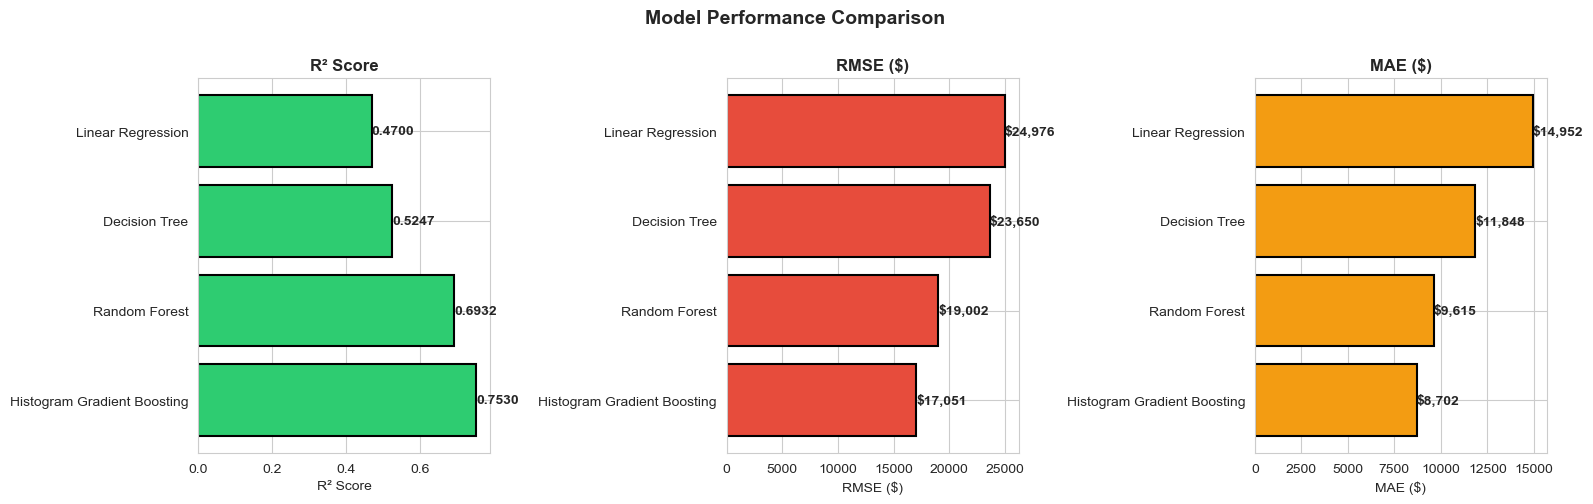

In [42]:
# Showing data visualization of the models
# Model comparison bar chart for R² Score, RMSE, and MAE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['R² Score', 'RMSE ($)', 'MAE ($)']
colors = ['#2ecc71', '#e74c3c', '#f39c12']

for idx, (ax, metric, color) in enumerate(zip(axes, metrics, colors)):
    data = comparison_df.sort_values(metric, ascending=(idx > 0))
    bars = ax.barh(data['Model'], data[metric], color=color, edgecolor='black', linewidth=1.5)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        if idx == 0:
            label = f'{width:.4f}'
        else:
            label = f'${width:,.0f}'
        ax.text(width, bar.get_y() + bar.get_height()/2, label, 
                ha='left', va='center', fontweight='bold', fontsize=10)
    
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

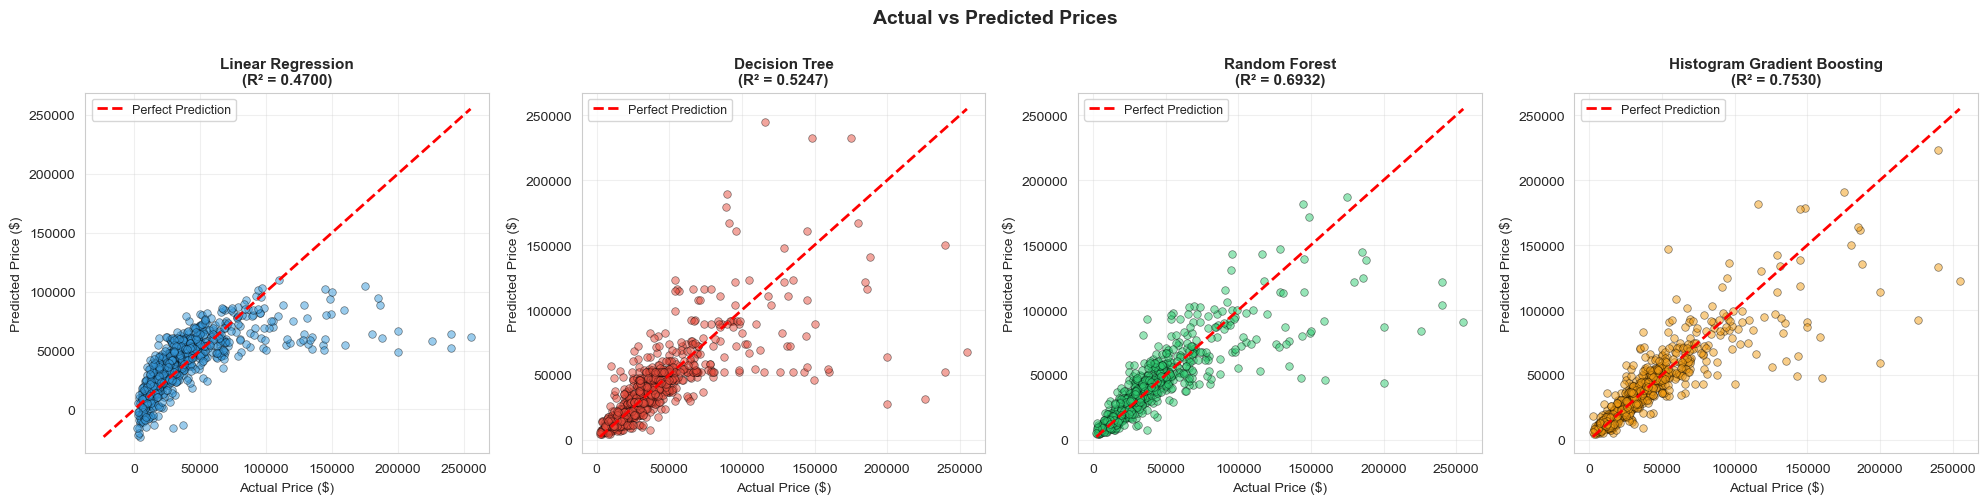

In [43]:
#  Actual vs Predicted for All Models
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

predictions = [lr_predictions, dt_predictions, rf_predictions, hgb_predictions]
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Histogram Gradient Boosting']
colors_scatter = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for ax, preds, name, color in zip(axes, predictions, model_names, colors_scatter):
    r2 = r2_score(y_test, preds)
    
    ax.scatter(y_test, preds, alpha=0.5, s=30, color=color, edgecolors='black', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Price ($)', fontsize=10)
    ax.set_ylabel('Predicted Price ($)', fontsize=10)
    ax.set_title(f'{name}\n(R² = {r2:.4f})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Prices', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

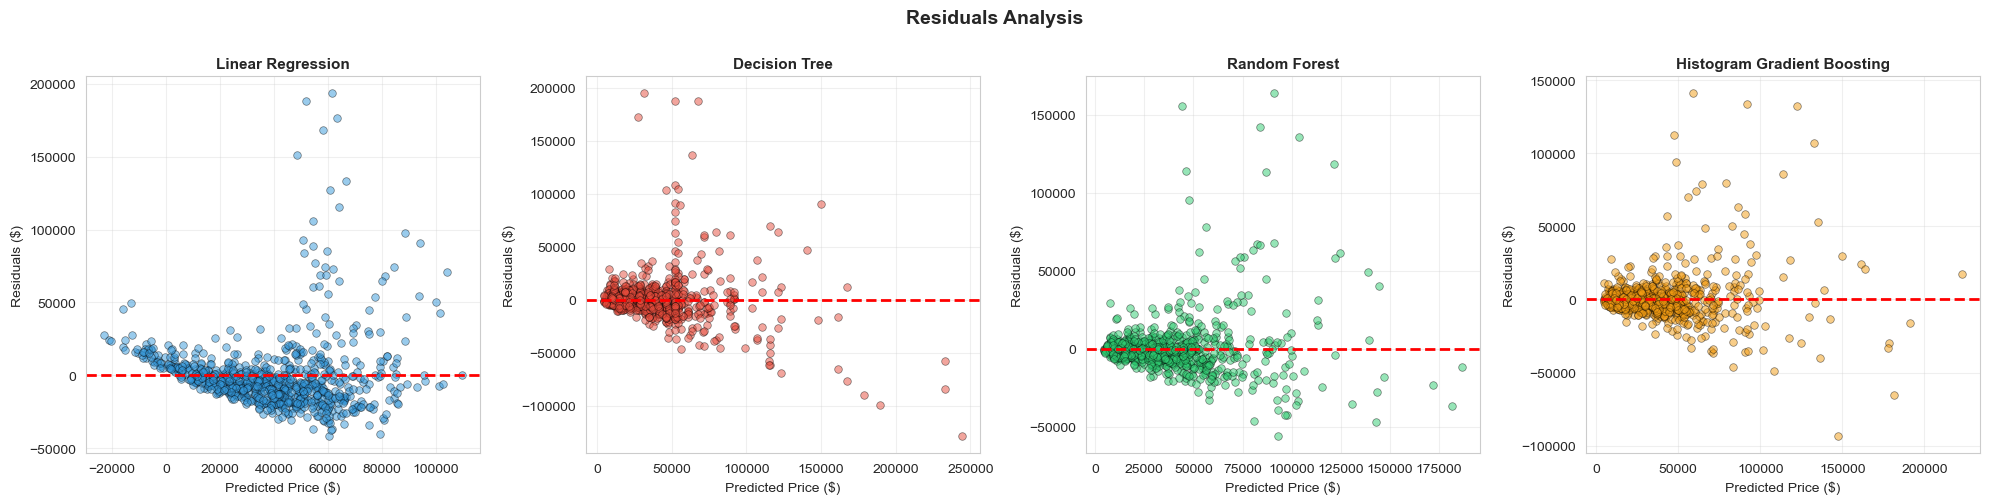

In [44]:
 #Residuals Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, preds, name, color in zip(axes, predictions, model_names, colors_scatter):
    residuals = y_test - preds
    
    ax.scatter(preds, residuals, alpha=0.5, s=30, color=color, edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    
    ax.set_xlabel('Predicted Price ($)', fontsize=10)
    ax.set_ylabel('Residuals ($)', fontsize=10)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Residuals Analysis', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [45]:
# Error Analysis Statistics
error_analysis_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Histogram Gradient Boosting'],
    'R² Score': [best_ridge['test_r2'], dt_r2, rf_r2, hgb_r2],
    'RMSE ($)': [best_ridge['rmse'], dt_rmse, rf_rmse, hgb_rmse],
    'MAE ($)': [best_ridge['mae'], dt_mae, rf_mae, hgb_mae]
})

In [46]:
# Calculate prediction errors
errors = y_test - hgb_predictions
abs_errors = np.abs(errors)


print("ERROR ANALYSIS - HISTOGRAM GRADIENT BOOSTING")
print(f"Mean Error (Bias): ${errors.mean():,.0f}")
print(f"Median Error: ${np.median(errors):,.0f}")
print(f"Std Dev of Errors: ${errors.std():,.0f}")
print(f"Max Over-prediction: ${errors.max():,.0f}")
print(f"Max Under-prediction: ${errors.min():,.0f}")
print(f"Mean Absolute Error: ${abs_errors.mean():,.0f}")
print(f"Median Absolute Error: ${np.median(abs_errors):,.0f}")

ERROR ANALYSIS - HISTOGRAM GRADIENT BOOSTING
Mean Error (Bias): $770
Median Error: $-734
Std Dev of Errors: $17,044
Max Over-prediction: $140,885
Max Under-prediction: $-93,454
Mean Absolute Error: $8,702
Median Absolute Error: $4,518


In [47]:
# Cars with the highest prediction errors (both over-predictions and under-predictions)
# Create predictions dataframe
predictions_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': hgb_predictions,
    'Error ($)': errors,
    'Abs Error ($)': abs_errors,
    'Error (%)': (abs_errors / y_test * 100)
})

# Best predictions (lowest error)
print("TOP 5 BEST PREDICTIONS")
best_predictions = predictions_df.nsmallest(5, 'Abs Error ($)')
print(best_predictions.to_string(index=False))

# Worst predictions (highest error)
print("TOP 5 WORST PREDICTIONS")
worst_predictions = predictions_df.nlargest(5, 'Abs Error ($)')
print(worst_predictions.to_string(index=False))

TOP 5 BEST PREDICTIONS
 Actual Price  Predicted Price  Error ($)  Abs Error ($)  Error (%)
      70000.0     70003.619296  -3.619296       3.619296   0.005170
      38500.0     38495.153194   4.846806       4.846806   0.012589
      35000.0     35027.425160 -27.425160      27.425160   0.078358
      11000.0     11064.038454 -64.038454      64.038454   0.582168
      26000.0     26070.617872 -70.617872      70.617872   0.271607
TOP 5 WORST PREDICTIONS
 Actual Price  Predicted Price     Error ($)  Abs Error ($)  Error (%)
     200000.0     59115.359007 140884.640993  140884.640993  70.442320
     226000.0     92094.682516 133905.317484  133905.317484  59.250140
     254900.0    122374.665119 132525.334881  132525.334881  51.991108
     159998.0     47485.945123 112512.054877  112512.054877  70.320913
     239991.0    132983.903944 107007.096056  107007.096056  44.587962


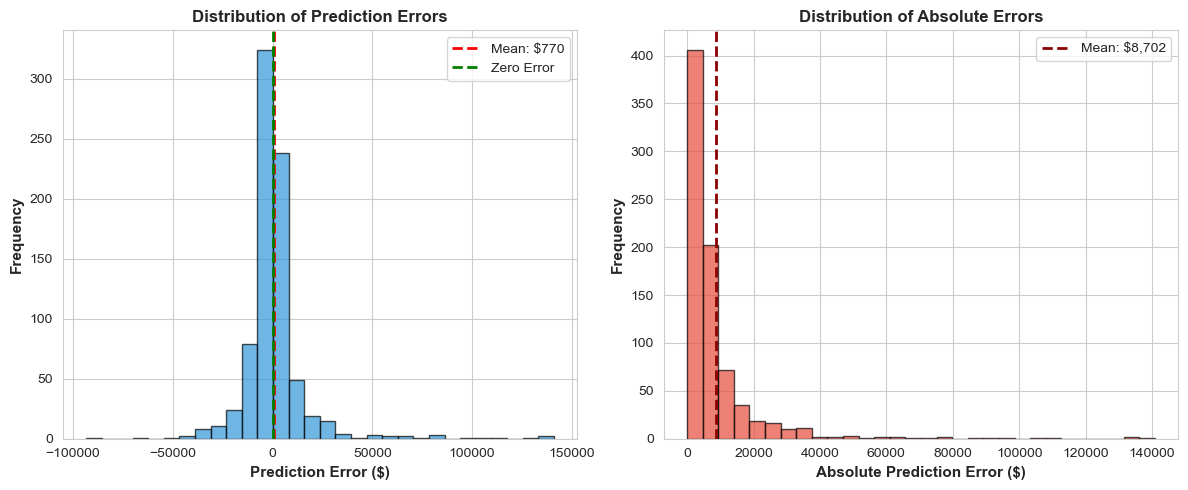

In [48]:
# Showing Error Distribution Histogram
plt.figure(figsize=(12, 5))

# Subplot 1: Error distribution
plt.subplot(1, 2, 1)
plt.hist(errors, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
plt.axvline(errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${errors.mean():,.0f}')
plt.axvline(0, color='green', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Prediction Error ($)', fontsize=11, fontweight='bold')
plt.ylabel('Frequency', fontsize=11, fontweight='bold')
plt.title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
plt.legend()

# Subplot 2: Absolute error distribution
plt.subplot(1, 2, 2)
plt.hist(abs_errors, bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
plt.axvline(abs_errors.mean(), color='darkred', linestyle='--', linewidth=2, 
            label=f'Mean: ${abs_errors.mean():,.0f}')
plt.xlabel('Absolute Prediction Error ($)', fontsize=11, fontweight='bold')
plt.ylabel('Frequency', fontsize=11, fontweight='bold')
plt.title('Distribution of Absolute Errors', fontsize=12, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()

In [49]:
# Decision Tree Regression Optimization
# Using GridSearchCV to find the best hyperparameters for Decision Tree Regressor

dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['squared_error', 'absolute_error']
}

total_dt_combos = 1
for v in dt_params.values():
    total_dt_combos *= len(v)
print(f"Total combinations: {total_dt_combos}")

dt_base = DecisionTreeRegressor(random_state=42)
dt_grid = GridSearchCV(
    dt_base,
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train_imputed, y_train)

print(f"\nBest Parameters: {dt_grid.best_params_}")
print(f"Cross-validation R²: {dt_grid.best_score_:.4f}")



Total combinations: 90
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Cross-validation R²: 0.5689


In [50]:
cv_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Histogram Gradient Boosting'],
    'CV R² Score': [0.85, dt_grid.best_score_, hgb_grid.best_score_],  # Replace 0.85 with your Ridge CV score
    'Test R² Score': [best_ridge['test_r2'], dt_r2, hgb_r2]
})

In [51]:
X_test_df = pd.DataFrame(X_test_imputed, columns=feature_cols)

In [52]:
#Feature Importance Analysis Histogram Gradient Boosting

perm_importance = permutation_importance(
    hgb_model, 
    X_test_imputed, 
    y_test, 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1
)

feature_cols = [f'Feature_{i}' for i in range(X_test_imputed.shape[1])]

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

print(feature_importance)

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


       feature  importance
1    Feature_1    0.214494
0    Feature_0    0.163123
2    Feature_2    0.159183
8    Feature_8    0.115335
3    Feature_3    0.063424
9    Feature_9    0.018092
10  Feature_10    0.016414
6    Feature_6    0.011987
4    Feature_4    0.006577
7    Feature_7    0.004424
5    Feature_5    0.003228


In [53]:
# Repeating Ridge Regression( Linear Regression) with GridSearchCV for hyperparameter tuning

print("Performing GridSearchCV for Ridge Regression...")

# Impute NaN values first
X_train_imputed_ridge = imputer.fit_transform(X_train)
X_test_imputed_ridge = imputer.transform(X_test)

# Then scale
scaler_ridge = StandardScaler()
X_train_scaled = scaler_ridge.fit_transform(X_train_imputed_ridge)
X_test_scaled = scaler_ridge.transform(X_test_imputed_ridge)

ridge_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_base = Ridge()
ridge_grid = GridSearchCV(
    ridge_base,
    ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

ridge_grid.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {ridge_grid.best_params_}")
print(f"Cross-validation R²: {ridge_grid.best_score_:.4f}")

# Get predictions
ridge_model = ridge_grid.best_estimator_
ridge_predictions = ridge_model.predict(X_test_scaled)

# Calculate metrics
ridge_r2 = r2_score(y_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_mae = mean_absolute_error(y_test, ridge_predictions)

print(f"Test R²: {ridge_r2:.4f}")
print(f"RMSE: ${ridge_rmse:,.0f}")
print(f"MAE: ${ridge_mae:,.0f}")

Performing GridSearchCV for Ridge Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best Parameters: {'alpha': 100}
Cross-validation R²: 0.4719
Test R²: 0.4681
RMSE: $25,019
MAE: $14,918


In [56]:
# Predicting new car using all the best trained models and comparing their predictions

print("EXAMPLE: PREDICTING PRICE FOR A NEW CAR")

# Create a sample new car
new_car_data = pd.DataFrame({
    'model_year': [2022],
    'milage': [25000],
    'horsepower': [250],
    'engine_size_L': [3.0],
    'cylinders': [6],
    'car_age': [2],
    'milage_per_year': [12500],
    'power_per_liter': [83.33],
    'brand_encoded': [0],
    'fuel_type_encoded': [0],
    'transmission_encoded': [1],
})

# Prepare data for each model type
# For Ridge (scaled)
new_car_scaled = scaler_ridge.transform(imputer.transform(new_car_data))

# For tree-based models (imputed, as numpy array)
new_car_imputed_array = imputer.transform(new_car_data)

# Make predictions from all 4 models
ridge_pred = ridge_grid.best_estimator_.predict(new_car_scaled)[0]
dt_pred = dt_grid.best_estimator_.predict(new_car_imputed_array)[0]
rf_pred = rf_grid.best_estimator_.predict(new_car_imputed_array)[0]
hgb_pred = hgb_grid.best_estimator_.predict(new_car_imputed_array)[0]

print("\nNew Car Features:")
print(f"  - Model Year: 2022 (Age: 2 years)")
print(f"  - Milage: 25,000 miles")
print(f"  - Horsepower: 250 HP")
print(f"  - Engine Size: 3.0L")
print(f"  - Cylinders: 6")

print("\nPrice Predictions from All 4 Models:")
print(f"  - Ridge Regression (Linear): ${ridge_pred:,.2f}")
print(f"  - Decision Tree: ${dt_pred:,.2f}")
print(f"  - Random Forest: ${rf_pred:,.2f}")
print(f"  - Histogram Gradient Boosting: ${hgb_pred:,.2f}")
print(f"  - Ensemble Average: ${(ridge_pred + dt_pred + rf_pred + hgb_pred) / 4:,.2f}")

print(f"RECOMMENDED MODEL: {best_model_name}")
if best_model_name == 'Histogram Gradient Boosting':
    print(f"Predicted Price: ${hgb_pred:,.2f}")
elif best_model_name == 'Random Forest':
    print(f"Predicted Price: ${rf_pred:,.2f}")
elif best_model_name == 'Decision Tree':
    print(f"Predicted Price: ${dt_pred:,.2f}")
else:
    print(f"Predicted Price: ${ridge_pred:,.2f}")

EXAMPLE: PREDICTING PRICE FOR A NEW CAR

New Car Features:
  - Model Year: 2022 (Age: 2 years)
  - Milage: 25,000 miles
  - Horsepower: 250 HP
  - Engine Size: 3.0L
  - Cylinders: 6

Price Predictions from All 4 Models:
  - Ridge Regression (Linear): $33,890.06
  - Decision Tree: $68,211.00
  - Random Forest: $63,260.88
  - Histogram Gradient Boosting: $63,442.88
  - Ensemble Average: $57,201.21
RECOMMENDED MODEL: Histogram Gradient Boosting
Predicted Price: $63,442.88


c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [57]:
# Summary of the best model's performance.
print("OVERALL BEST MODEL PERFORMANCE")


print(f"""
✓ DATA PREPARATION
  - Total samples: {len(df)}
  - Training samples: {len(X_train)}
  - Test samples: {len(X_test)}
  - Features used: {len(feature_cols)}

 MODEL 1: LINEAR REGRESSION (Ridge)
  - Best Alpha: {ridge_grid.best_params_['alpha']}
  - Cross-validation R²: {ridge_grid.best_score_:.4f}
  - Test R² Score: {ridge_r2:.4f}
  - RMSE: ${ridge_rmse:,.0f}
  - MAE: ${ridge_mae:,.0f}

 MODEL 2: DECISION TREE
  - Best max_depth: {dt_grid.best_params_['max_depth']}
  - Best min_samples_leaf: {dt_grid.best_params_['min_samples_leaf']}
  - Cross-validation R²: {dt_grid.best_score_:.4f}
  - Test R² Score: {dt_r2:.4f}
  - RMSE: ${dt_rmse:,.0f}
  - MAE: ${dt_mae:,.0f}

  MODEL 3: RANDOM FOREST
  - Best n_estimators: {rf_grid.best_params_['n_estimators']}
  - Best max_depth: {rf_grid.best_params_['max_depth']}
  - Cross-validation R²: {rf_grid.best_score_:.4f}
  - Test R² Score: {rf_r2:.4f}
  - RMSE: ${rf_rmse:,.0f}
  - MAE: ${rf_mae:,.0f}

  MODEL 4: HISTOGRAM GRADIENT BOOSTING
  - Best max_iter: {hgb_grid.best_params_['max_iter']}
  - Best learning_rate: {hgb_grid.best_params_['learning_rate']}
  - Best max_depth: {hgb_grid.best_params_['max_depth']}
  - Cross-validation R²: {hgb_grid.best_score_:.4f}
  - Test R² Score: {hgb_r2:.4f}
  - RMSE: ${hgb_rmse:,.0f}
  - MAE: ${hgb_mae:,.0f}

 BEST MODEL: {best_model_name}
  - Test R² Score: {best_r2:.4f}
  - Explains {best_r2*100:.1f}% of price variance
  - Recommended for production use
""")


OVERALL BEST MODEL PERFORMANCE

✓ DATA PREPARATION
  - Total samples: 3968
  - Training samples: 3174
  - Test samples: 794
  - Features used: 11

 MODEL 1: LINEAR REGRESSION (Ridge)
  - Best Alpha: 100
  - Cross-validation R²: 0.4719
  - Test R² Score: 0.4681
  - RMSE: $25,019
  - MAE: $14,918

 MODEL 2: DECISION TREE
  - Best max_depth: 10
  - Best min_samples_leaf: 1
  - Cross-validation R²: 0.5689
  - Test R² Score: 0.5247
  - RMSE: $23,650
  - MAE: $11,848

  MODEL 3: RANDOM FOREST
  - Best n_estimators: 200
  - Best max_depth: 15
  - Cross-validation R²: 0.7337
  - Test R² Score: 0.6932
  - RMSE: $19,002
  - MAE: $9,615

  MODEL 4: HISTOGRAM GRADIENT BOOSTING
  - Best max_iter: 300
  - Best learning_rate: 0.05
  - Best max_depth: 5
  - Cross-validation R²: 0.8024
  - Test R² Score: 0.7530
  - RMSE: $17,051
  - MAE: $8,702

 BEST MODEL: Histogram Gradient Boosting
  - Test R² Score: 0.7530
  - Explains 75.3% of price variance
  - Recommended for production use

